# Classificazione Patologie ECG con CNN Embedded
### Tentativo 6: combinazione di tutte le tecniche validate

**Dataset**: MIT-BIH Arrhythmia Database (PhysioNet)
**Tecniche combinate**: RR interval ausiliario (confermato utile per S) + data augmentation label-preserving su F + class weights bilanciati + monitoraggio Macro F1 per Early Stopping (invece di val_loss, dominato da N)

## 0. Avvio rapido (richiede il salvataggio con RR interval, Sezione 5bis)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt

SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'

X_train = np.load(f'{SALVA_DIR}/X_train.npy')
y_train = np.load(f'{SALVA_DIR}/y_train.npy')
rr_train = np.load(f'{SALVA_DIR}/rr_train.npy')
X_val = np.load(f'{SALVA_DIR}/X_val.npy')
y_val = np.load(f'{SALVA_DIR}/y_val.npy')
rr_val = np.load(f'{SALVA_DIR}/rr_val.npy')
X_test = np.load(f'{SALVA_DIR}/X_test.npy')
y_test = np.load(f'{SALVA_DIR}/y_test.npy')
rr_test = np.load(f'{SALVA_DIR}/rr_test.npy')

print('Dataset (con RR interval) ricaricato da Drive:')
print(f'Training:   {X_train.shape}, RR: {rr_train.shape}')
print(f'Validation: {X_val.shape}, RR: {rr_val.shape}')
print(f'Test:       {X_test.shape}, RR: {rr_test.shape}')

Mounted at /content/drive
Dataset (con RR interval) ricaricato da Drive:
Training:   (75395, 300), RR: (75395,)
Validation: (14911, 300), RR: (14911,)
Test:       (19140, 300), RR: (19140,)


## 1. Setup ambiente

In [ ]:
!pip install wfdb -q

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

## 2. Download completo del dataset (48 record) + mappatura AAMI

In [ ]:
record_names = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

dataset = {}

for rec_name in record_names:
    record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
    ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')

    campioni_validi = []
    classi_valide = []
    for campione, simbolo in zip(ann.sample, ann.symbol):
        if simbolo in aami_map:
            campioni_validi.append(campione)
            classi_valide.append(aami_map[simbolo])

    dataset[rec_name] = {
        'signal': record.p_signal,
        'fs': record.fs,
        'beat_samples': np.array(campioni_validi),
        'beat_labels': np.array(classi_valide)
    }
    print(f'Record {rec_name}: {len(campioni_validi)} battiti validi')

print(f'\nTutti i {len(record_names)} record scaricati')

## 3. Preprocessing: filtro passa-banda

In [ ]:
from scipy.signal import butter, filtfilt

CANALE = 0

def filtro_passabanda(segnale, fs, lowcut=0.5, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, segnale)

for rec_name in dataset:
    segnale_grezzo = dataset[rec_name]['signal'][:, CANALE]
    dataset[rec_name]['signal_filtered'] = filtro_passabanda(segnale_grezzo, dataset[rec_name]['fs'])

print('Filtro passa-banda applicato a tutti i record.')

## 4. Segmentazione + calcolo RR interval

RR interval = distanza in campioni dal battito precedente nello stesso record. Il primo battito di ogni record riceve l'RR mediano del record.

In [ ]:
FINESTRA_PRIMA = 100
FINESTRA_DOPO = 200

X = []
y = []
record_id = []
beat_position = []
rr_interval = []

for rec_name in dataset:
    segnale = dataset[rec_name]['signal_filtered']
    campioni_battiti = dataset[rec_name]['beat_samples']
    classi_battiti = dataset[rec_name]['beat_labels']

    diff_rr = np.diff(campioni_battiti)
    rr_mediano = np.median(diff_rr) if len(diff_rr) > 0 else 0

    for idx, (campione, classe) in enumerate(zip(campioni_battiti, classi_battiti)):
        inizio = campione - FINESTRA_PRIMA
        fine = campione + FINESTRA_DOPO
        if inizio < 0 or fine > len(segnale):
            continue

        segmento = segnale[inizio:fine]
        media = np.mean(segmento)
        std = np.std(segmento)
        segmento_normalizzato = (segmento - media) / (std + 1e-8)

        rr = (campione - campioni_battiti[idx - 1]) if idx > 0 else rr_mediano

        X.append(segmento_normalizzato)
        y.append(classe)
        record_id.append(rec_name)
        beat_position.append(campione)
        rr_interval.append(rr)

X = np.array(X)
y = np.array(y)
record_id = np.array(record_id)
beat_position = np.array(beat_position)
rr_interval = np.array(rr_interval, dtype=float)

print(f'Segmenti totali estratti: {len(X)}')

## 5. Split Train / Validation / Test per paziente

In [ ]:
from sklearn.model_selection import train_test_split

record_unici = np.array(record_names)
record_train, record_valtest = train_test_split(record_unici, test_size=0.30, random_state=42)
record_val, record_test = train_test_split(record_valtest, test_size=0.50, random_state=42)

mask_train = np.isin(record_id, record_train)
mask_val = np.isin(record_id, record_val)
mask_test = np.isin(record_id, record_test)

X_train, y_train, rr_train = X[mask_train], y[mask_train], rr_interval[mask_train]
X_val, y_val, rr_val = X[mask_val], y[mask_val], rr_interval[mask_val]
X_test, y_test, rr_test = X[mask_test], y[mask_test], rr_interval[mask_test]

print(f'Training:   {X_train.shape[0]} segmenti')
print(f'Validation: {X_val.shape[0]} segmenti')
print(f'Test:       {X_test.shape[0]} segmenti')

## 5bis. Salvataggio su Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'
os.makedirs(SALVA_DIR, exist_ok=True)

np.save(f'{SALVA_DIR}/X_train.npy', X_train)
np.save(f'{SALVA_DIR}/y_train.npy', y_train)
np.save(f'{SALVA_DIR}/rr_train.npy', rr_train)
np.save(f'{SALVA_DIR}/X_val.npy', X_val)
np.save(f'{SALVA_DIR}/y_val.npy', y_val)
np.save(f'{SALVA_DIR}/rr_val.npy', rr_val)
np.save(f'{SALVA_DIR}/X_test.npy', X_test)
np.save(f'{SALVA_DIR}/y_test.npy', y_test)
np.save(f'{SALVA_DIR}/rr_test.npy', rr_test)

print('Dataset salvato su Google Drive in:', SALVA_DIR)

## 6. Codifica etichette, normalizzazione RR interval, reshape

In [2]:
classe_to_int = {classe: i for i, classe in enumerate(sorted(np.unique(np.concatenate([y_train, y_val, y_test]))))}
int_to_classe = {i: classe for classe, i in classe_to_int.items()}
num_classi = len(classe_to_int)
print('Mappa classi -> interi:', classe_to_int)

y_train_int = np.array([classe_to_int[c] for c in y_train])
y_val_int = np.array([classe_to_int[c] for c in y_val])
y_test_int = np.array([classe_to_int[c] for c in y_test])

rr_media = rr_train.mean()
rr_std = rr_train.std()

rr_train_norm = (rr_train - rr_media) / (rr_std + 1e-8)
rr_val_norm = (rr_val - rr_media) / (rr_std + 1e-8)
rr_test_norm = (rr_test - rr_media) / (rr_std + 1e-8)

X_train_r = X_train.reshape(-1, X_train.shape[1], 1)
X_val_r = X_val.reshape(-1, X_val.shape[1], 1)
X_test_r = X_test.reshape(-1, X_test.shape[1], 1)

print(f'Forma X_train: {X_train_r.shape}, RR train: {rr_train_norm.shape}')

Mappa classi -> interi: {np.str_('F'): 0, np.str_('N'): 1, np.str_('Q'): 2, np.str_('S'): 3, np.str_('V'): 4}
Forma X_train: (75395, 300, 1), RR train: (75395,)


## 7. Data augmentation mirata sulla classe F (solo training set)

Jitter temporale, rumore gaussiano lieve, scaling di ampiezza sui soli 422 esempi reali di F. Validation e test restano dati reali intatti.

In [3]:
def augmenta_segmento(segmento, rng):
    aug = segmento.copy()
    shift = rng.integers(-5, 6)
    aug = np.roll(aug, shift)
    aug = aug + rng.normal(0, 0.03, size=aug.shape)
    fattore_scala = rng.uniform(0.9, 1.1)
    aug = aug * fattore_scala
    return aug

rng = np.random.default_rng(42)

indice_F = classe_to_int['F']
idx_F_train = np.where(y_train_int == indice_F)[0]
print(f'Esempi reali di F nel training: {len(idx_F_train)}')

N_COPIE_PER_ESEMPIO = 8

X_aug_list, rr_aug_list, y_aug_list = [], [], []

for idx in idx_F_train:
    segmento_originale = X_train_r[idx, :, 0]
    rr_originale = rr_train_norm[idx]
    for _ in range(N_COPIE_PER_ESEMPIO):
        X_aug_list.append(augmenta_segmento(segmento_originale, rng))
        rr_aug_list.append(rr_originale)
        y_aug_list.append(indice_F)

X_aug = np.array(X_aug_list).reshape(-1, X_train_r.shape[1], 1)
rr_aug = np.array(rr_aug_list)
y_aug = np.array(y_aug_list)

X_train_final = np.concatenate([X_train_r, X_aug], axis=0)
rr_train_final = np.concatenate([rr_train_norm, rr_aug], axis=0)
y_train_final = np.concatenate([y_train_int, y_aug], axis=0)

print(f'Training dopo augmentation: {len(y_train_final)} esempi (F: {(y_train_final == indice_F).sum()})')

Esempi reali di F nel training: 422
Training dopo augmentation: 78771 esempi (F: 3798)


## 8. Architettura a doppio input: forma d'onda + RR interval

In [4]:
from tensorflow.keras import layers, models, Input

def costruisci_modello_duale(lunghezza_finestra, num_classi):
    input_forma = Input(shape=(lunghezza_finestra, 1), name='forma_donda')
    x = layers.Conv1D(16, kernel_size=9, padding='same')(input_forma)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(32, kernel_size=7, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)

    input_rr = Input(shape=(1,), name='rr_interval')
    r = layers.Dense(16, activation='relu')(input_rr)
    r = layers.Dense(8, activation='relu')(r)

    combinato = layers.Concatenate()([x, r])
    output = layers.Dense(num_classi, activation='softmax')(combinato)

    return models.Model(inputs=[input_forma, input_rr], outputs=output)

model = costruisci_modello_duale(X_train_r.shape[1], num_classi)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ forma_donda         │ (None, 300, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 300, 16)   │        160 │ forma_donda[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 300, 16)   │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 300, 16)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 150, 16)   │          0 │ re_lu[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 150, 32)   │      3,616 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 150, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 75, 32)    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 75, 64)    │     10,304 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr_interval         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 75, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         32 │ rr_interval[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        136 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5)         │        365 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,061 (58.83 KB)

 Trainable params: 14,837 (57.96 KB)

 Non-trainable params: 224 (896.00 B)

## 9. Callback per il monitoraggio del Macro F1

`val_loss` e' dominata dalla classe maggioritaria N. Calcoliamo il Macro F1 sul validation set a ogni epoca per Early Stopping e per decidere quali pesi conservare.

In [5]:
import tensorflow as tf
from sklearn.metrics import f1_score

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val_list, y_val_int):
        super().__init__()
        self.X_val_list = X_val_list
        self.y_val_int = y_val_int

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val_list, verbose=0), axis=1)
        macro_f1 = f1_score(self.y_val_int, y_pred, average='macro', zero_division=0)
        logs['val_macro_f1'] = macro_f1
        print(f' -- val_macro_f1: {macro_f1:.4f}')

## 10. Training combinato

Class weights bilanciati (senza capping estremo, l'augmentation ha gia' ridotto lo sbilanciamento assoluto di F) + monitoraggio Macro F1 per Early Stopping.

In [6]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

pesi = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_final), y=y_train_final)
class_weights_dict = dict(zip(np.unique(y_train_final), pesi))
print('Class weights:', class_weights_dict)

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

macro_f1_cb = MacroF1Callback([X_val_r, rr_val_norm], y_val_int)

early_stop = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history = model.fit(
    [X_train_final, rr_train_final], y_train_final,
    validation_data=([X_val_r, rr_val_norm], y_val_int),
    epochs=60,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=[macro_f1_cb, early_stop, reduce_lr],
    verbose=1
)

Class weights: {np.int64(0): np.float64(4.148025276461295), np.int64(1): np.float64(0.25665830373725196), np.int64(2): np.float64(2.6375690607734805), np.int64(3): np.float64(6.7440924657534245), np.int64(4): np.float64(2.9826202196137825)}
Epoch 1/60
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5451 - loss: 0.8414 -- val_macro_f1: 0.3472
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 59s 46ms/step - accuracy: 0.7338 - loss: 0.5363 - val_accuracy: 0.8537 - val_loss: 0.4958 - val_macro_f1: 0.3472 - learning_rate: 3.0000e-04
Epoch 2/60
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9209 - loss: 0.2485 -- val_macro_f1: 0.3697
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 55s 45ms/step - accuracy: 0.9330 - loss: 0.2060 - val_accuracy: 0.9360 - val_loss: 0.2423 - val_macro_f1: 0.3697 - learning_rate: 3.0000e-04
Epoch 3/60
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9495 - loss: 0.1590 -- val_macro_f1: 0.3801
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.9514 - loss: 0.16

## 11. Valutazione su Validation Set

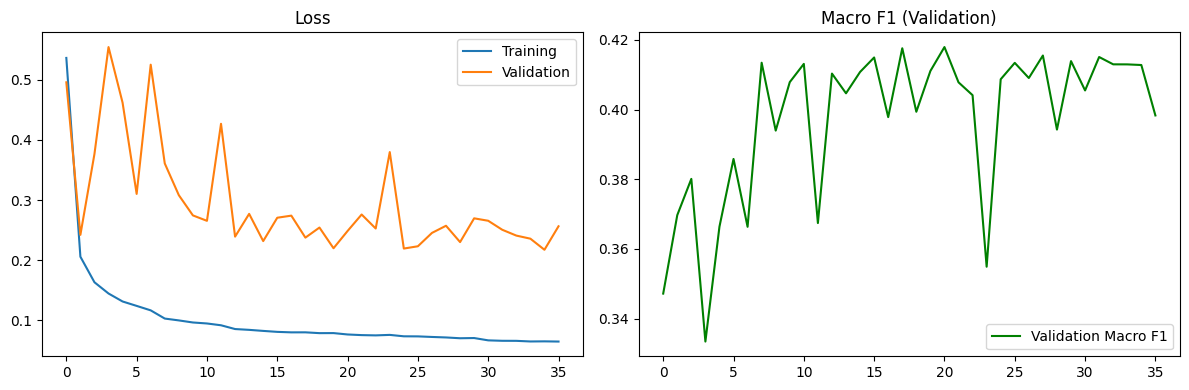

466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


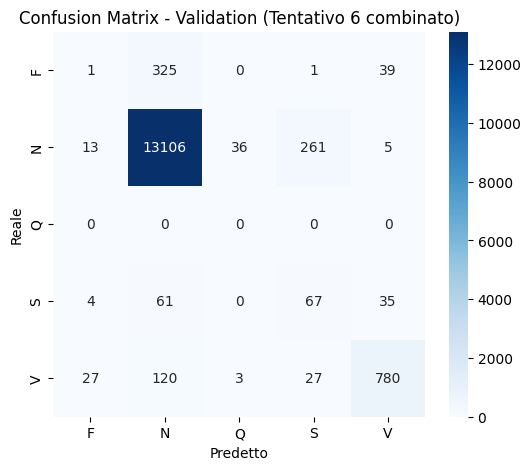

              precision    recall  f1-score   support

           F       0.02      0.00      0.00       366
           N       0.96      0.98      0.97     13421
           Q       0.00      0.00      0.00         0
           S       0.19      0.40      0.26       167
           V       0.91      0.82      0.86       957

    accuracy                           0.94     14911
   macro avg       0.42      0.44      0.42     14911
weighted avg       0.93      0.94      0.93     14911



In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['val_macro_f1'], label='Validation Macro F1', color='green')
axes[1].set_title('Macro F1 (Validation)')
axes[1].legend()
plt.tight_layout()
plt.show()

y_val_pred = np.argmax(model.predict([X_val_r, rr_val_norm]), axis=1)
nomi_classi = [int_to_classe[i] for i in range(num_classi)]

cm = confusion_matrix(y_val_int, y_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nomi_classi, yticklabels=nomi_classi, cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.title('Confusion Matrix - Validation (Tentativo 6 combinato)')
plt.show()

print(classification_report(y_val_int, y_val_pred, target_names=nomi_classi, zero_division=0))